# Housing

## Data

Get data using pandas. The function returns **pandas DataFrame** object that contains all the data

In [116]:
import csv
import os
import pandas as pd
import numpy as np
from pandas import DataFrame
from webencodings import labels

# get data path
HOUSING_PATH = os.path.join('datasets', 'housing')

def extract_housing_data(housing_path: str =HOUSING_PATH) -> pd.DataFrame:
    # join base path with exact filename
    csv_housing_path = os.path.join(housing_path, 'housing.csv')

    # return pandas DataFrame
    return pd.read_csv(csv_housing_path)

See top five data rows

In [117]:
csv_data = extract_housing_data()
csv_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


See base data info via pandas DataFrame `info()`
As we can see below, dataset contains 20640 entries.

But, we're missing 207 of `total_bedrooms` features. We need to care about that soon.

In [118]:
csv_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


See amount of `ocean_proximity` values.

In [119]:
csv_data['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

As you can see, the `ocean_proximity` feature type is **object**. This type can contain any of python objects, often - strings.

In our dataset, the feature can acquire to 5 string states.

`describe()` method shows summary of all **numeric** attributes

In [120]:
csv_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


All null values are ignored.

- *std* row shows *standard deviation*, which measures how values are dispersed.
- *25% 50% 75%* are *percentiles*. For example, if 50th percentile is 75 on some feature, it means that all sorted observation by this feature have a value lower than 75. Often 25th and 75th percentiles called as *first quartile* and *third quartile*

Here is how you can build histogram to every **DataFrame** features:

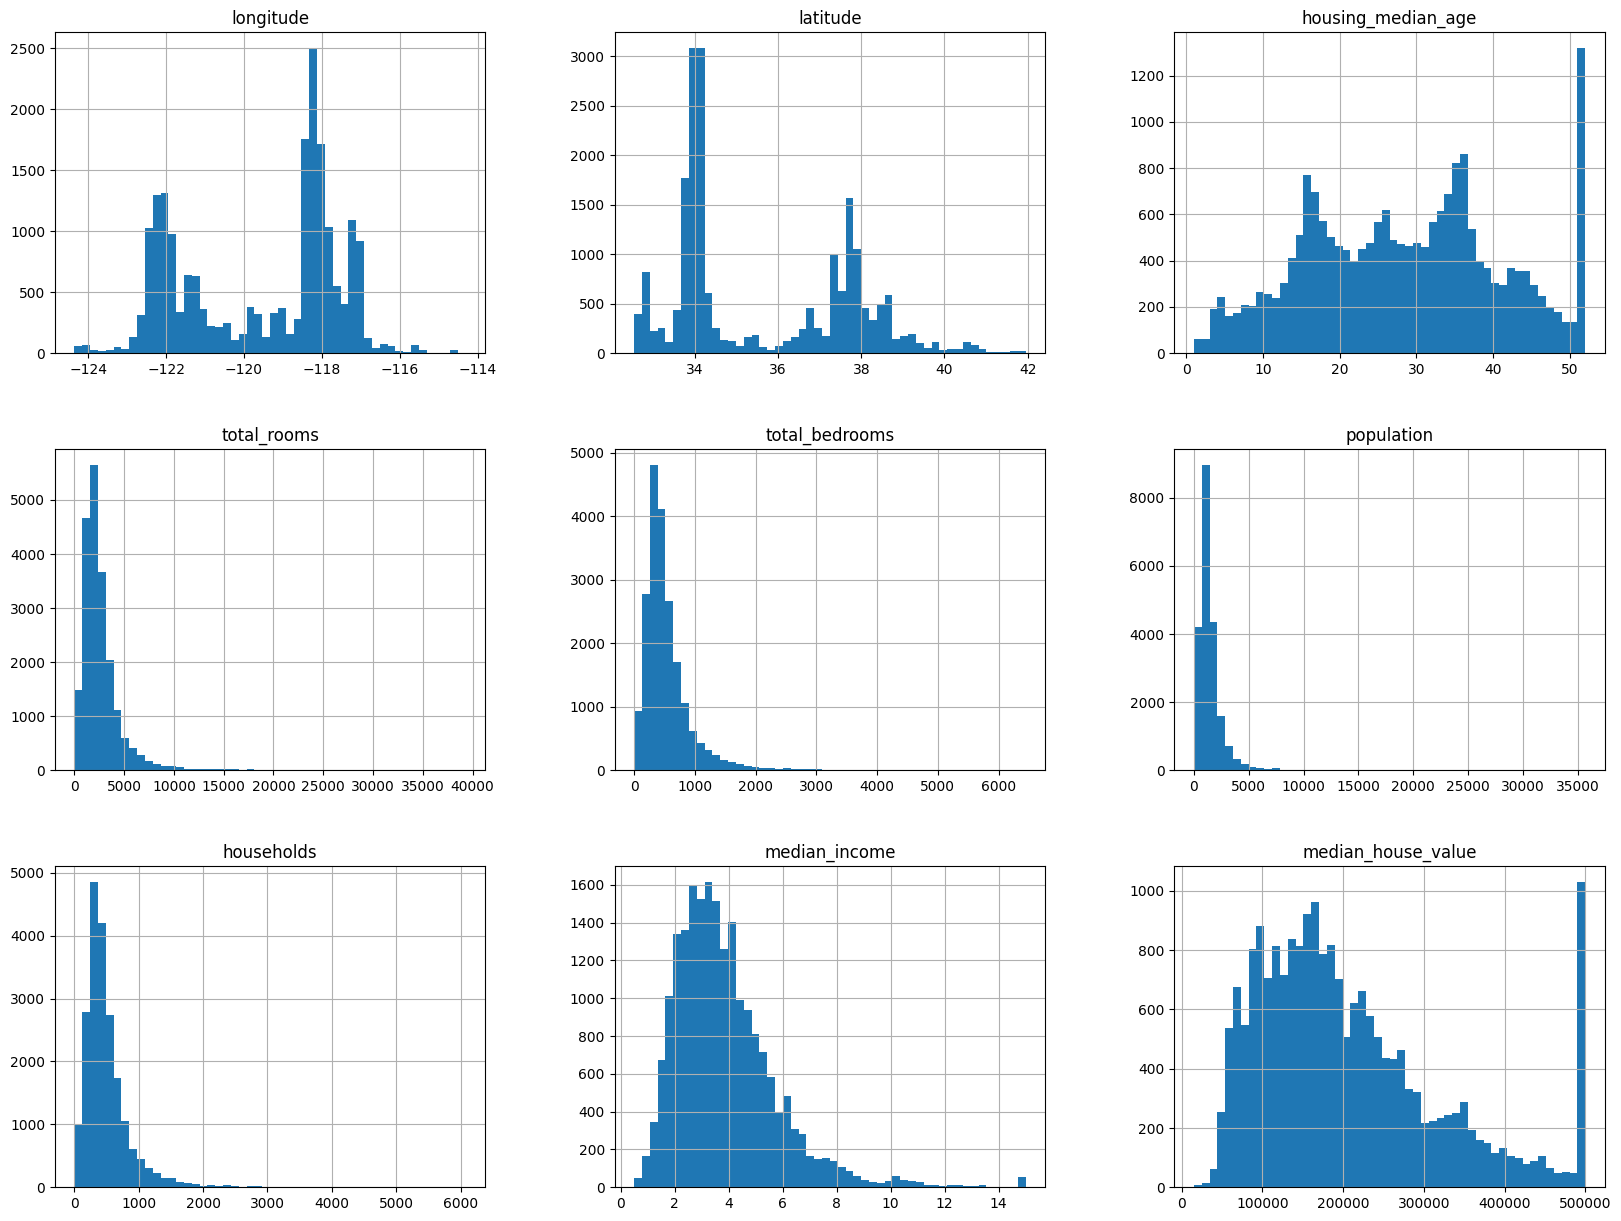

In [121]:
%matplotlib inline
import matplotlib.pyplot as plt

csv_data.hist(bins=50, figsize=(20, 15))
plt.show()

- `%matplotlib inline` Is a notebook magic command. That tells Jupyter to draw all histograms in notebook directly.

- `hist()` method draws all features histograms, `bins` argument divides output by number of columns.

1. The **Median Income** feature does not look like a standard income in US dollars. Because **each number** represents **tens of thousands** of dollars.
2. Median House value is our *labels* *(cause in our case we use supervised learning)*, and it's features is *capped* at 500_000 mark. ML algorithm may learn that prices **never** go beyond that limit.
3. Some of the features are **heavily tailed**. For example: population, it has 80% of its entries under 2000 milestone and long and small tail of rare entries. This may take it a bit harder for some ML algorithms to detect patterns.

To resolve this, we have two options:
- Collect proper data from regions, where data was capped
- Remove these regions from the dataset

## Create Test

Separating test data from training is a bit complicated. Often, it isn't good approach - just randomly pick 20% of all entries, especially, on small datasets.
Because it leads to train data won't be representative and static _(data always different with random picking approach)_ to train data.

In [122]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(csv_data, test_size=0.2, random_state=42) # Not good for smaller datasets

So, we can choose most important **labels** and stratify them. It means to separate data to categories, like on hist below.

<Axes: >

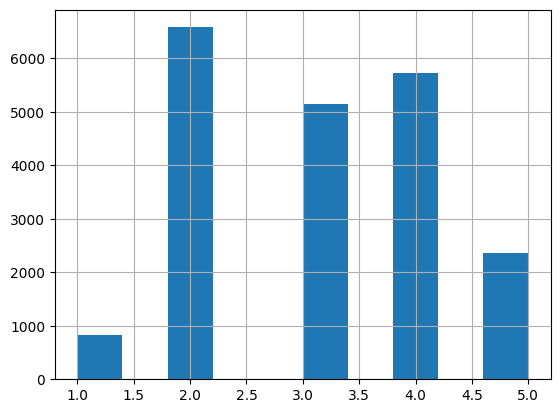

In [123]:
csv_data["income_category"] = pd.cut(csv_data["median_income"], bins=[0, 1.5, 3.0, 4.0, 6., np.inf], labels=[1, 2, 3, 4, 5])
csv_data["income_category"].hist()

Using `pandas.cut()` we're creating stratified income feature from `income_category`.

> `income_category` represents tens of thousands as one integer!

Line `bins=[0, 1.5, 3.0, 4.0, 6., np.inf` creates categories separation. For example: values 0.7 and 4.5 will be in first and fourth categories. `np.inf` represents infinity

Alright, now we can separate our train and test data.
Scikit-learn provides class `StratifiedShuffleSplit`, that can randomly but with almost identical income proportions.

In [124]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in splitter.split(X=csv_data, y=csv_data["income_category"]):
    strat_train_set: DataFrame = csv_data.loc[train_index]
    strat_test_set: DataFrame = csv_data.loc[test_index]

Let's look closer at this code.

Firstly we're creating `StratifiedShuffleSplit`, and passing amount of splits, size of test set and random state, to ensure that test set will always be static.

Then we're getting indexes, and getting them from original `DataFrame` object. Using `loc[index]` that looks to the left column that represents indexes. Note that `train_index` and `test_index` are lists of indexes

Now, we can check that data separated correctly. Using created `income_category` feature, dividing number of entries of each category with length of full dataset.

In [125]:
print(f"Test set: \n {strat_test_set['income_category'].value_counts() / len(strat_test_set)} \n")
print(f" Test set: \n {strat_train_set['income_category'].value_counts() / len(strat_train_set)}")

Test set: 
 income_category
2    0.318798
4    0.277374
3    0.249516
5    0.114341
1    0.039971
Name: count, dtype: float64 

 Test set: 
 income_category
2    0.318859
4    0.277374
3    0.249516
5    0.114462
1    0.039789
Name: count, dtype: float64


As we can see, stratified categories proportions are almost equal. It means that data **representable in both directions**.

Great job.

# Discover and Visualize the Data to Gain Insights

We have taken a quick glance at the data. Now the goal is to go into more depth.

Let's copy our separated training set, so we can play with it without harming original dataset

In [126]:
housing: DataFrame = strat_train_set.copy()

## Visualizing Geographical Data

Since there is geographical data, we can create scatterplot to visualize location of every entry

<Axes: xlabel='latitude', ylabel='longitude'>

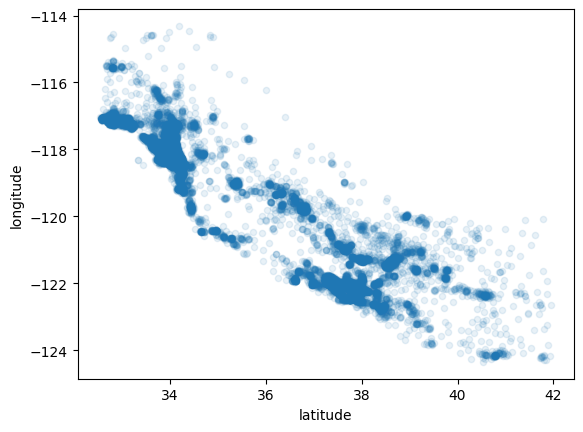

In [127]:
housing.plot(kind="scatter", x="latitude", y="longitude", alpha=0.1)

Looks like California! We're setting `alpha` to 0.1 to see **high density** of data.

You can clearly see the high-density areas, namely the Bay
Area and around Los Angeles and San Diego, plus a long line of fairly high density in
the Central Valley, in particular around Sacramento and Fresno.

Since our brains are masters of finding patterns. So let's add color map of `median_house_value`.

<Axes: xlabel='longitude', ylabel='latitude'>

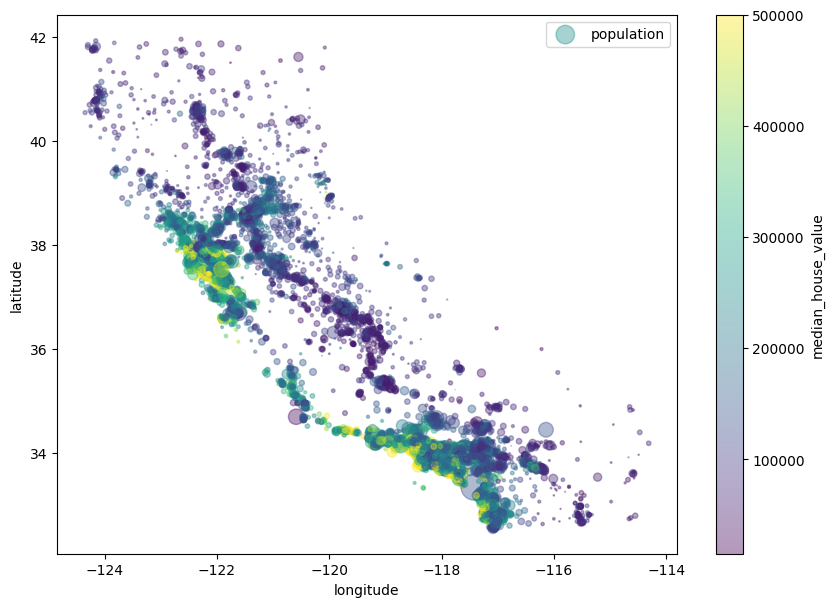

In [128]:
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=housing["population"]/100, label="population", figsize=(10, 7),
    c="median_house_value", cmap=plt.get_cmap("viridis"), colorbar=True
)

Now we definitely can say that house prices are very much related to the location _(e.g. close to ocean)_ and to the population density.

So the ocean proximity feature will be helpful. Although in Northern California the housing prices in coastal district are not too high, so it isn't a simple rule.

## Looking for Correlations

Since our dataset isn't ot large, we can compute **the Standard Correlation Coefficient** between every pair of attributes via `corr()` method

In [129]:
# Dropping feature because in newer versions corr() doesn't skip non numeric values
housing_dropped = housing.copy()
housing_dropped = housing_dropped.drop("ocean_proximity", axis=1)

housing_corr = housing_dropped.corr()
print(housing_corr["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688992
income_category       0.631498
total_rooms           0.136702
housing_median_age    0.107835
households            0.067330
total_bedrooms        0.050345
population           -0.021021
longitude            -0.048203
latitude             -0.142081
Name: median_house_value, dtype: float64


The **Standard Correlation Coefficient** ranges from -1 to 1. When it's 1 it indicates perfect positive linear correlations, -1 - a perfect negative linear correlation. 0 - no correlation.

Result gives us some correlations. For example, the median house value tends to grow when the median income goes up. Also, you can see small negative correlations between the latitude and median house value, when we go north - prices slightly go down.

Another way to find correlations is to use `scatter_matrix` from **pandas**:

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

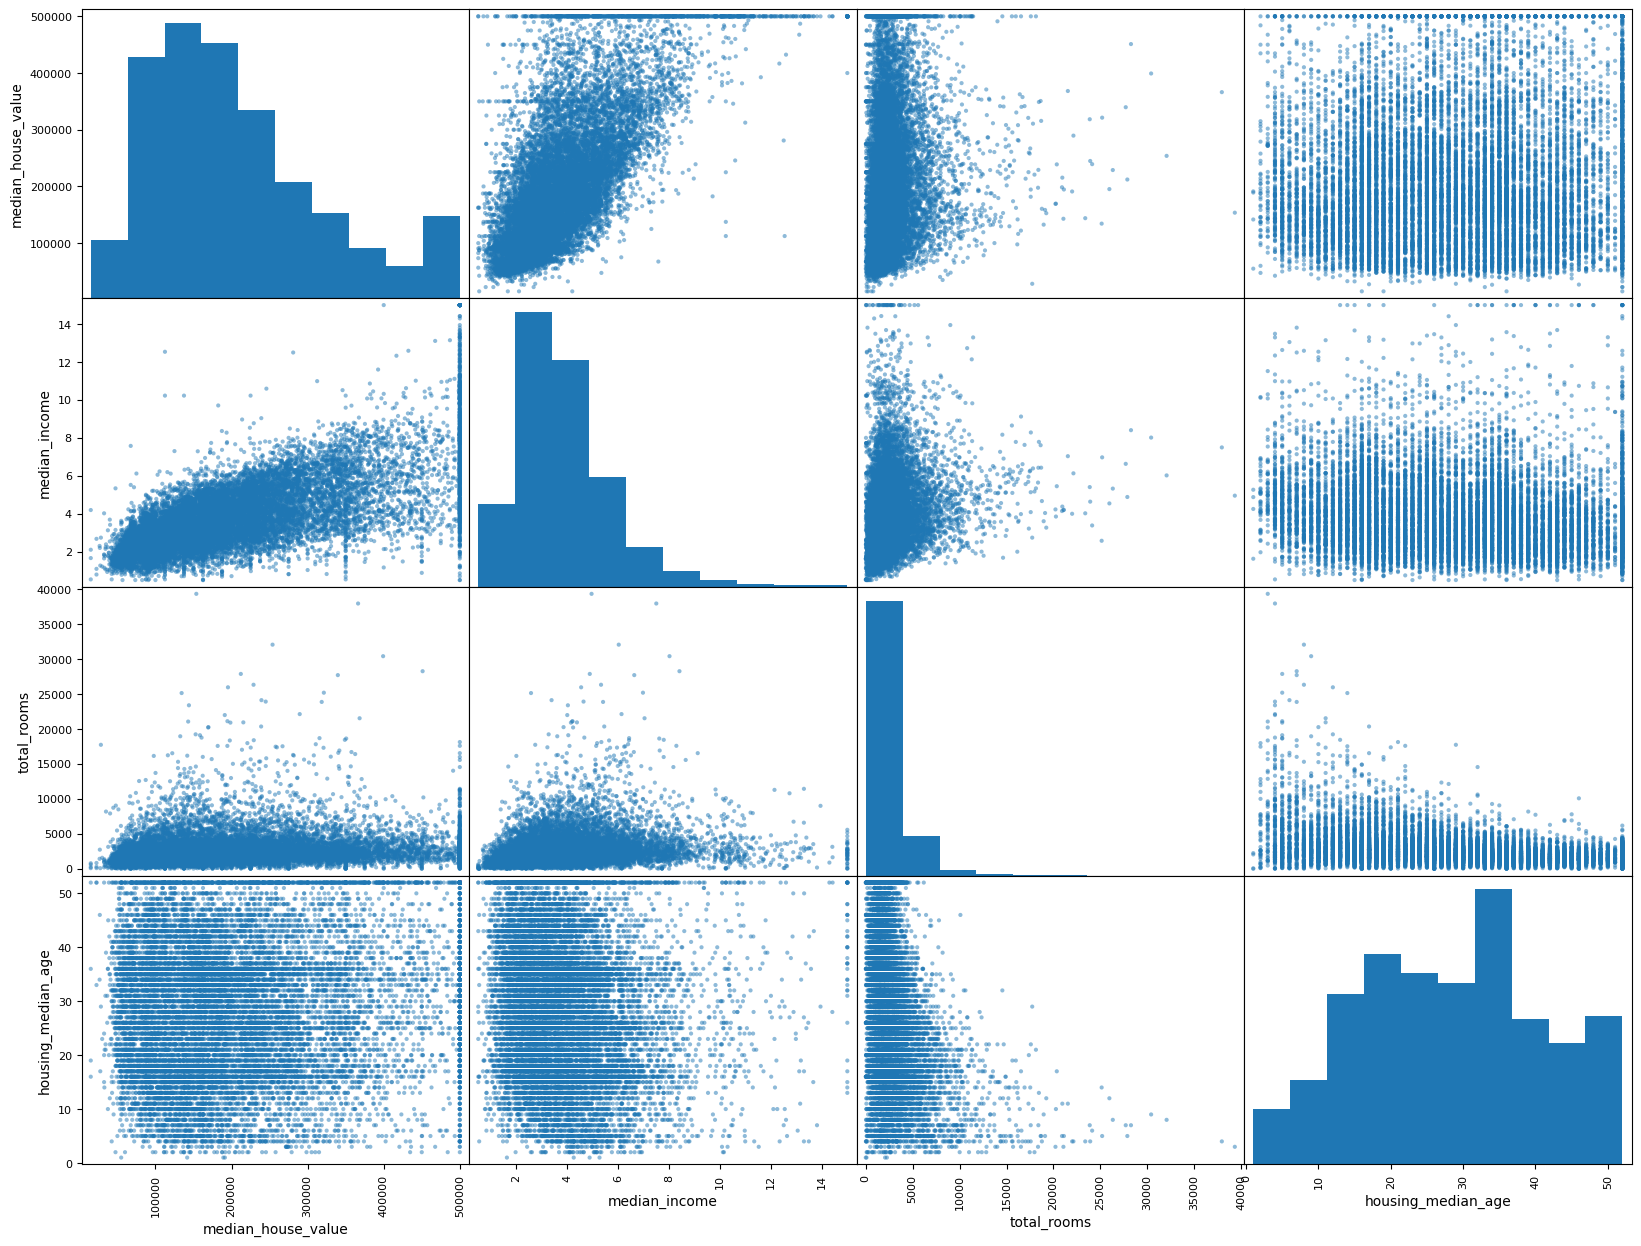

In [130]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(20, 15), alpha=0.5)

We got matrix. That represents correlations between every feature.

And it's clear that `median_income` correlates with `median_house_value`, because we see **natural growth** on plot *(Indexes: (1,0))*.

If we look at the median income correlation with median house value, we can notice straight line at 500 000 and 350 000 dollars, it's our caps. It's good idea to remove this data artifacts to prevent our algorithm of learning them.

## Experimenting with Attribute Combinations

At the previous sections we discovered our date. We identified few data artifacts that we may want to clean up, found interesting correlations between features. Also noticed that some of the features have **heavily tailed distribution,** and we want to transform them.

One thing we want to do before preparing data to the ML algorithm, is to try out different feature combinations. For example number of rooms isn't very useful attribute if you don't know how many households there are. What you really want is number of rooms per householder. Similar to the total number of bedrooms by It's now very useful, unless you know number of rooms :)

In [131]:
housing["rooms_per_householder"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"] = housing["population"]/housing["households"]

Now, let's create correlation matrix again

In [132]:
housing_dropped = housing.copy()
housing_dropped = housing_dropped.drop("ocean_proximity", axis=1)

matrix_cor = housing_dropped.corr()
print(matrix_cor["median_house_value"].sort_values(ascending=False))

median_house_value          1.000000
median_income               0.688992
income_category             0.631498
rooms_per_householder       0.147264
total_rooms                 0.136702
housing_median_age          0.107835
households                  0.067330
total_bedrooms              0.050345
population                 -0.021021
population_per_household   -0.021529
longitude                  -0.048203
latitude                   -0.142081
bedrooms_per_room          -0.266411
Name: median_house_value, dtype: float64


As we can see. Feature `bedrooms_per_room` correlates much more with median house value than `total_rooms`, it means that housing with lower bedrooms/rooms ratio more expensive. The point of this step it about **getting insights** that will help you to build good prototype. This is an iterative process, you can go back at any time to gain more insights.

# Prepare the Data for Machine Learning Algorithm

Let's separate our **predictors** *(labels)*, since we don't want to necessarily apply same transformations to the predictors.

In [133]:
housing = strat_train_set.drop("median_house_value", axis=1) # Not modifying strat_train_set
housing_labels = strat_train_set["median_house_value"].copy()


For data preparing stage, you should write a **function**, to be able to use it with future datasets or your project.

Firstly, lets get rid of missing data in `total_bedroom` feature. There are three options:
- Get rid of corresponding entries
- Get rid of whole feature
- Set values to median *(Our choice)*


You can accomplish it like this:

In [134]:
# bedrooms_median = housing["total_bedrooms"].median()
# housing["total_bedrooms"].fillna(bedrooms_median, inplace=True) # inplace=True says to change this column itself, not returning updated values

Scikit-Learn provides convenient class to take care of missing values: `SimpleImputer`

In [135]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
housing_num = housing.drop("ocean_proximity", axis=1) # Dropping all non-numeric attributes, since they can't have median
imputer.fit(housing_num)

imputer.statistics_

array([-118.495 ,   34.26  ,   29.    , 2121.    ,  432.    , 1164.5   ,
        409.    ,    3.5409,    3.    ])

The `imputer` computed the median of each feature and stored the result in its `statistics_` variable. We can't be sure that new data won't have missing values, so now we can safely apply the `imputer` all future data.

Now we can use this trained `imputer` to transform training dataset by replacing missing values with medians

In [136]:
X = imputer.transform(housing_num) # x: Plaint numpy array

It returns plain **NumPy array**, if you want to put it back to DataFrame, it's simple:

In [137]:
housing_transformed = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

## Handling Text and Categorical Attributes

In our dataset, we have one **categorial** attribute, **ocean proximity**.

In [138]:
housing_category = housing[["ocean_proximity"]]
housing_category.head(10)

,ocean_proximity
3945,<1H OCEAN
7086,<1H OCEAN
5553,<1H OCEAN
14437,NEAR OCEAN
10691,<1H OCEAN
10403,<1H OCEAN
14548,NEAR OCEAN
3592,<1H OCEAN
2694,INLAND
12177,INLAND


Machine Learning algorithms prefer to work with numbers. So let' convert these categories from text to numbers using **Scikit-Learn OrdinalEncoder**.

In [139]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_category)
housing_cat_encoded[:10]

array([[0.],
       [0.],
       [0.],
       [4.],
       [0.],
       [0.],
       [4.],
       [0.],
       [1.],
       [1.]])

In [140]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

Each category represents one number, from 0 to 4. But, ML algorithm will assume that two nearby values more similar than two distant values.

To fix this issue, we can use **One Hot Encoder**. It will create row for each district with 0 and 1, where 1 is single and represents to which category it belongs to.

In [141]:
from sklearn.preprocessing import OneHotEncoder
onehot_encoder = OneHotEncoder()
housing_cat_1hot = onehot_encoder.fit_transform(housing_category)
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

Encoder returns **SciPy sparse matrix**, to reduce cost of memory. The matrix stores only 1's positions. This matrix can easily be passed to ML algorithms. If you want to convert it to **NumPy array**, call this method:

In [142]:
housing_cat_1hot.toarray()

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.]], shape=(16512, 5))

In [143]:
onehot_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

Note, that if a categorial attribute has large number of possible categories, one hot encoding will result in a large number of features. This may slow down training and degrade performance. To solve this issue you can use **embeddings**.

## Custom Transformers

Sometimes you will want to write your own **Transformers**, such as: cleanup, combining attributes. And you want them to work seamlessly with Scikit-Learn **Pipeline** etc.

In [144]:
from sklearn.base import BaseEstimator, TransformerMixin

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

    def __init__(self, add_bedrooms_per_room: bool = True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        rooms_per_household = X[:, self.rooms_ix] / X[:, self.households_ix]
        population_per_household = X[:, self.population_ix] / X[:, self.households_ix]

        if self.add_bedrooms_per_room:
            bedrooms_per_rooms = X[:, self.bedrooms_ix] / X[:, self.rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_rooms]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

att_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attributes = att_adder.transform(housing.values) # NumPy ndarray

`np.c_[...]` adds columns to the right to existing ones in `X`. `..._ix` represents column id. `add_bedrooms_per_room` works as a **hyperparameter**.

We are inheriting BaseEstimator and TransformerMixin to ensure that this Transformer will work Scikit-Learn tools.

## Feature Scaling

ML models usually work better when numerical attributes have same scales. For example in our housing data the total amount of rooms ranges from about 6 to 39,320, while the median income range from 0 to 15.

There are two common ways to get attributes have the same scale:
- min-max scaling - shifts and rescales attribute, so it will end up ranging from 0 to 1. Scikit-learn provides **MinMaxScaler Transformer**
- Standardization - ranges attributes that the median is 0. It leads to all entries will have same value. Scikit-Learn provides **StandardScaler**

Min-max better for models that expect 0-1 range. Standardization much less affected by outliners.

## Transformation Pipelines

**Pipelines** help to transform data in exact order you need.

Here is our pipeline to numerical attributes:

In [145]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("attributes_adder", CombinedAttributesAdder()),
    ("attributes_scaler", StandardScaler())
])

housing_num_transformed = numeric_pipeline.fit_transform(housing_num)

Last estimator must be transformers *(must have `fit_transform` method)*. And names can be anything you like, as long they are unique and don't contain double underscores.

This pipeline will add new custom features and scale all the numeric attributes.

But, this pipeline transforms only numeric attributes. Let's combine this pipeline with another one using **ColumnTransformer**

In [146]:
from sklearn.compose import ColumnTransformer

num_attributes = list(housing_num)
categorial_attribute = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num_pipeline", numeric_pipeline, num_attributes),
    ("categorial_pipeline", OneHotEncoder(), categorial_attribute)
])

housing_prepared = full_pipeline.fit_transform(housing)

Note than `list(housing_num)` returns list of all columns names. Each tuple in ColumnTransformer must contain name, a transformer, list of names *(or indices)* of columns that transformer should be applied to.

Note that the OneHotEncoder returns a sparse matrix, while the num_pipeline returns
a dense matrix. When there is such a mix of sparse and dense matrices, the Colum
nTransformer estimates the density of the final matrix (i.e., the ratio of nonzero
cells), and it returns a sparse matrix if the density is lower than a given threshold (by
default, sparse_threshold=0.3).

# Select and Train Model

`We framed the problem, got the data, explored, prepared, separated it. And now we ready to to select and train ML model.

Let's run simple **Linear Regression Model**

In [147]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Done. Let's try it out on a few instances from the training set

In [148]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)

print(f"Predictions: ", lin_reg.predict(some_data_prepared))
print(f"Labels: ", list(some_labels))

Predictions:  [309256.77522209 259181.93442447 243963.69913485 263710.20042212
 122066.68768846]
Labels:  [258600.0, 173900.0, 247600.0, 112500.0, 162500.0]


It's working, but not accurate. Let's get models **RMSE**

In [149]:
from sklearn.metrics import mean_squared_error

housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
float(lin_rmse)

67801.91245780997

Now we see that typical error in predicting median house value is 67801. Not great, but better than nothing.

So let's try to firstly choose more powerful model, like **Decision Tree**. Which is more capable of in finding nonlinear relationships.

In [150]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
float(tree_rmse)

0.0

Wow! An absolutely perfect model! No. It's clear that model **overfit** the data.

As we know, it is a bad practise, testing model on a previously separated test set if you not sure about model launching.
So let's try to split our training dataset into training and test, train model against smaller training set and validate it on a new smaller validation dataset. It is called **Cross Validation**

In [151]:
from sklearn.model_selection import cross_val_score

tree_scores = cross_val_score(tree_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-tree_scores)
tree_rmse_scores

array([73339.61937544, 69257.54113998, 66165.49519018, 66120.7601935 ,
       66920.22416534, 72344.34412667, 67943.1377314 , 69217.96965995,
       70705.19087049, 71606.86075379])

In [152]:
def display_scores(scores) -> None:
    print(f"Scores: {scores}")
    print(f"Median: {scores.mean()}")
    print(f"Standard Deviation: {scores.std()}")

display_scores(tree_rmse_scores)

Scores: [73339.61937544 69257.54113998 66165.49519018 66120.7601935
 66920.22416534 72344.34412667 67943.1377314  69217.96965995
 70705.19087049 71606.86075379]
Median: 69362.11432067453
Standard Deviation: 2455.3974833489724


Now, we see that out Decision Tree doesn't look as good as it did earlier. Standard deviation means that scores are approximately 69498 ±2516

The **Cross Validation** allows to gain more insights of model testing.

So let's compute the same scores for **Linear Regression**, just to be sure.

In [153]:
lin_reg_scores = cross_val_score(lin_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
lin_reg_scores_rmse = np.sqrt(-lin_reg_scores)
display_scores(lin_reg_scores_rmse)

Scores: [68558.48142686 67341.77238316 70095.66347134 65191.16951317
 66963.10582401 71230.13692883 67183.91481346 68963.34141309
 65622.81740094 70249.25214913]
Median: 68139.96553239968
Standard Deviation: 1914.2540021298178


As we can see, our **Decision Tree** badly overfits data, and performs even worse than the **Linear Regression** model.

Let's try one more model, called **RandomForestRegressor**, that works by training many Decision Trees on a random subset of the features, then averaging out their predictions. Building model on top of many other models is called **Ensemble Learning**.

In [154]:
from sklearn.ensemble import RandomForestRegressor

ran_forest_reg = RandomForestRegressor(n_jobs=-1)
ran_forest_reg.fit(housing_prepared, housing_labels)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [155]:
ran_forest_scores = cross_val_score(ran_forest_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
ran_forest_scores_rmse = np.sqrt(-ran_forest_scores)
display_scores(ran_forest_scores_rmse)

forest_predictions = ran_forest_reg.predict(some_data_prepared)
forest_rmse = mean_squared_error(some_labels, forest_predictions)
print(f"Test Data Predictions: {float(np.sqrt(forest_rmse))}")

Scores: [50452.75002164 50011.03619394 48319.3753033  48061.07483428
 48645.61049844 50636.9683321  48214.70492191 48549.05619282
 48731.4296997  53364.41443291]
Median: 49498.6420431031
Standard Deviation: 1572.7875777825122
Test Data Predictions: 14596.084001131947


Wow! This is much better. But as we can see the model is slightly overfits training data, because **RMSE** of a test data is much lower, approx 18969. Possible solution - **reqularize** it, or get more training data.

# Fine-Tune Model

Now we have a list of promising models. Let's fine-tune them to minimize average error.

## Grid Search

One option will be to fiddle the **hyperparameters** manually, until you find a great combination. A very tedious work. So instead, we should use Scikit-Learn **GridSearchCV**

In [156]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"n_estimators": [90, 100, 110], "max_features": [6, 8, 10, 12]},
    {"bootstrap": [False], "n_estimators": [3, 10, 15], "max_features": [2, 3, 4, 5, 6]},
]

ran_forest_reg = RandomForestRegressor(n_jobs=-1)

grid_search = GridSearchCV(ran_forest_reg, param_grid, scoring="neg_mean_squared_error", cv=5, return_train_score=True, refit=True) # To fit best model found automatically
grid_search.fit(housing_prepared, housing_labels)

grid_search.best_params_

{'max_features': 8, 'n_estimators': 100}

This **param grid** tells Scikit-Learn to firstly test $ 3 \times 4 = 12 $ combinations of `n_estimators` and `max_features` params, and secondly to test $ 2 \times 3 = 6$ combinations of another features.

In total, we will have 18 differently tuned models, for 10 rounds of **cross validation**. It means that we will run 180 **RandomForestRegressors**.

If parameters value is min or max of entered you should play with them, and try out different combinations.

Get the best estimator:

In [157]:
grid_search.best_estimator_

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,8
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [158]:
cv_results = grid_search.cv_results_
# zip() -> https://www.geeksforgeeks.org/python/zip-in-python/
results = [(float(np.sqrt(-mean_score_neg)), params) for mean_score_neg, params in zip(cv_results['mean_test_score'], cv_results['params'])]
results.sort(key=lambda x: x[0])
for result in results:
    print(f"{result[0]}: {result[1]}")

49428.908319426504: {'max_features': 8, 'n_estimators': 100}
49443.03473259333: {'max_features': 8, 'n_estimators': 110}
49513.237577362546: {'max_features': 6, 'n_estimators': 100}
49515.65097597327: {'max_features': 6, 'n_estimators': 110}
49538.10855540357: {'max_features': 10, 'n_estimators': 110}
49555.890149187544: {'max_features': 10, 'n_estimators': 90}
49570.49044075817: {'max_features': 8, 'n_estimators': 90}
49590.84023420317: {'max_features': 6, 'n_estimators': 90}
49597.32167127412: {'max_features': 10, 'n_estimators': 100}
49603.25684146912: {'max_features': 12, 'n_estimators': 100}
49635.23744790051: {'max_features': 12, 'n_estimators': 110}
49732.625765155186: {'max_features': 12, 'n_estimators': 90}
50283.66246428436: {'bootstrap': False, 'max_features': 6, 'n_estimators': 15}
50747.241140705155: {'bootstrap': False, 'max_features': 5, 'n_estimators': 15}
50854.058704274525: {'bootstrap': False, 'max_features': 4, 'n_estimators': 15}
51422.82622587715: {'bootstrap': Fa

Code like this allows you to see all evaluation scores. As we can see, the best **hyperparameter combination** is `{'max_features': 8, 'n_estimators': 100}`

You can also treat some of the data preparation steps hyperparameters. For example whether add or not to add a Feature, e.g. `add_bedrooms_per_room`.

## Randomized Search

The grid approach great when you explore few combinations, like in previous example. But when hyperparameters space is large, it is preferable to use **Randomized Search** instead.

It is instead of trying every possible combinations - on each iteration chooses random value for each hyperparameter at every iteration. This approach has two main benefits:
- f you let the randomized search run for, say, 1,000 iterations, this approach will
explore 1,000 different values for each hyperparameter (instead of just a few val‐
ues per hyperparameter with the grid search approach)
- Simply setting number of iterations provide more control over putted budget.

## Ensemble Methods

Another way to fine-tune is to try combine the models that perform best, it's called **Ensemble Learning**. For example Random Forests perform better than the individual Decision Trees.

## Analyze the Best Models and Their Errors

You will often gain more insights on the problem by inspecting the best models. **RandomForestRegressor** provides importance of each feature for making accurate predictions:

In [159]:
feature_importances = grid_search.best_estimator_.feature_importances_

extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
cat_encoder = full_pipeline.named_transformers_["categorial_pipeline"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attributes + extra_attribs + cat_one_hot_attribs
importance_labels = sorted(zip(feature_importances, attributes), reverse=True)

for importance, label in importance_labels:
    print(f"{label} - {importance}")


median_income - 0.2855610072793394
INLAND - 0.14305810351971898
income_category - 0.13741149780215575
pop_per_hhold - 0.10840871946405808
longitude - 0.0634546106624524
latitude - 0.0590742166901767
bedrooms_per_room - 0.05017959620146521
housing_median_age - 0.046524121540522836
rooms_per_hhold - 0.03347273986032662
total_bedrooms - 0.016170104442190133
total_rooms - 0.015717160055762135
population - 0.015434082840079265
households - 0.014554356358080233
<1H OCEAN - 0.0047584713342363845
NEAR OCEAN - 0.0034163595690387093
NEAR BAY - 0.0027492679547135943
ISLAND - 5.5584425683693734e-05


*ISLAND doesn't have 8 points in importance, it's just scientific record, it means $NUM \times 10^{-5}$*

With this information you may want to drop some of the less useful features. Also, it can help you understand the system, how it works and how to fix problems.

# Evaluate System on the Test Set

Now, it's time to evaluate bext model on a test dataset. That we stratified earlier.
Note that you don't want to call `fit_transform()` - you don't want to fit thhe test set!

In [160]:
final_model = grid_search.best_estimator_

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

prepared_X = full_pipeline.transform(X_test) # not fit_transform()

final_predictions = final_model.predict(prepared_X)

final_mse = mean_squared_error(y_test, final_predictions)

print(f"Final RMSE: {float(np.sqrt(final_mse))}")


Final RMSE: 50002.445643511426


Usually, test dataset results are slightly worse that on the cross validation ones.

So now you need to present your solution. Document everything, and create
nice presentations with clear visualizations and easy-to-remember statements. In this Califor‐
nia housing example, the final performance of the system is not better than the
experts’ price estimates, which were often off by about 20%, but it may still be a good
idea to launch it, especially if this frees up some time for the experts so they can work
on more interesting and productive tasks.

# Exercises

## 1. SVR

In [161]:
from sklearn.svm import SVR

svr = SVR()

svr_cross_scores = cross_val_score(svr, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=3)
svr_cross_scores_rmse = np.sqrt(-svr_cross_scores)
display_scores(svr_cross_scores_rmse)

Scores: [117408.59095412 117437.09819127 118988.61005133]
Median: 117944.7663989084
Standard Deviation: 738.2006699517208


# 2. Randomized Search

In [162]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = [
    { "kernel": ["linear", "rbf"], "C": [0.1, 1, 10, 100, 1000], "gamma": ['scale', 'auto', 0.01, 0.1, 1]}
]

svr_ran_search = RandomizedSearchCV(svr, param_grid, scoring="neg_mean_squared_error", cv=3, n_jobs=-1, return_train_score=True, refit=True)
svr_ran_search.fit(housing_prepared, housing_labels)

print(svr_ran_search.best_params_)

results = [(float(np.sqrt(-mean_score_neg)), params) for mean_score_neg, params in zip(svr_ran_search.cv_results_['mean_test_score'], svr_ran_search.cv_results_['params'])]
for result in results:
    print(f"RMSE: {result[0]}")
    print(f"Params: {result[1]}")
    print("=====")

{'kernel': 'linear', 'gamma': 1, 'C': 1000}
RMSE: 83226.43283867548
Params: {'kernel': 'linear', 'gamma': 0.01, 'C': 10}
=====
RMSE: 69633.57757260771
Params: {'kernel': 'linear', 'gamma': 1, 'C': 1000}
=====
RMSE: 117966.81081663782
Params: {'kernel': 'rbf', 'gamma': 0.1, 'C': 1}
=====
RMSE: 98136.70322699452
Params: {'kernel': 'rbf', 'gamma': 0.1, 'C': 100}
=====
RMSE: 118135.90556804447
Params: {'kernel': 'rbf', 'gamma': 0.01, 'C': 1}
=====
RMSE: 118285.77397625976
Params: {'kernel': 'rbf', 'gamma': 1, 'C': 0.1}
=====
RMSE: 109798.0024584382
Params: {'kernel': 'linear', 'gamma': 'scale', 'C': 1}
=====
RMSE: 69633.57757260771
Params: {'kernel': 'linear', 'gamma': 'auto', 'C': 1000}
=====
RMSE: 83226.43283867548
Params: {'kernel': 'linear', 'gamma': 1, 'C': 10}
=====
RMSE: 96458.03186896858
Params: {'kernel': 'rbf', 'gamma': 'auto', 'C': 100}
=====


# 3. Transformer that selects only the most important features

In [163]:
def top_k_features_selector(importances: np.ndarray, k: int):
    """Note that importances type must be np.ndarray"""

    with_indices = []

    for i, importance in enumerate(importances):
        with_indices.append((importance, i))

    with_indices_sorted = sorted(with_indices, key=lambda x: x[0], reverse=True)[:k]

    return [importance[1] for importance in with_indices_sorted]

In [164]:
class TopFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feature_importances, k):
        self.feature_importances = feature_importances
        self.k = k

    def fit(self, X, y=None):
        self.feature_indices_ = top_k_features_selector(self.feature_importances, self.k)
        return self

    def transform(self, X):
        return X[:, self.feature_indices_]

In [165]:
preparation_and_top_feature_selection = Pipeline([
    ("preparation", full_pipeline),
    ("top_features", TopFeatureSelector(feature_importances=feature_importances, k=5)),
])

In [166]:
housing_prepared_top_k_features = preparation_and_top_feature_selection.fit_transform(housing)
housing_prepared_top_k_features[:3]

array([[ 1.18498330e+00,  0.00000000e+00,  1.72612486e+00,
         1.39567536e-03,  4.72268311e-01],
       [ 5.56509730e-01,  0.00000000e+00,  8.13863758e-01,
        -5.60119312e-03,  7.81728780e-01],
       [-4.01635796e-01,  0.00000000e+00, -9.83973493e-02,
        -6.93803030e-02,  5.97050758e-01]])

# 4. Single pipeline that does data preparation and predictions

In [167]:
prepare_select_and_predict_pipeline = Pipeline([
    ("preparation", full_pipeline),
    ("top_features", TopFeatureSelector(feature_importances=feature_importances, k=5)),
    ("prediction", SVR(**svr_ran_search.best_params_))
])

prepare_select_and_predict_pipeline.fit(housing, housing_labels)

,steps,"[('preparation', ...), ('top_features', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_pipeline', ...), ('categorial_pipeline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [168]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]

print(f"Predictions: {prepare_select_and_predict_pipeline.predict(some_data)}")
print(f"Labels: {list(some_labels)}")

Predictions: [290741.32509819 246917.7120252  182104.22367266 208757.04535298
 137982.15688225]
Labels: [258600.0, 173900.0, 247600.0, 112500.0, 162500.0]


# 5. Use GridSearchCV to explore preparation options

In [169]:
param_grid = [{
    "preparation__num_pipeline__imputer__strategy": ["mean", "median", "most_frequent"],
    "top_features__k": list(i for i in range(1, len(list(feature_importances)) + 1)), # feature_importances length equal to number of features after full data preparation
}]

pipeline_grid_search = GridSearchCV(prepare_select_and_predict_pipeline, param_grid, scoring="neg_mean_squared_error", cv=5, return_train_score=True, refit=True, n_jobs=-1, verbose=2) # verbose=2 to display each params combination score

pipeline_grid_search.fit(housing, housing_labels)

pipeline_grid_search.best_params_

Fitting 5 folds for each of 51 candidates, totalling 255 fits


{'preparation__num_pipeline__imputer__strategy': 'most_frequent',
 'top_features__k': 13}

In [170]:
float(np.sqrt(-pipeline_grid_search.best_score_))

70264.52629686157